# Geo Experiment with Differences-in-Differences (DiD)

## Introduction

In **geo experiments**, we randomize at the geography level (e.g., regions, DMAs, countries): some geos receive a treatment (e.g., a new feature or campaign), others remain in control. We cannot assign treatment at the user level, so we compare aggregate outcomes (e.g., revenue per user, conversion rate) between treatment and control geos over time.

**Differences-in-Differences (DiD)** estimates the treatment effect by comparing the *change* in the outcome from pre to post period in treatment geos to the *change* in control geos. The control geos' change is used as the counterfactual: what would have happened to treatment geos in the absence of treatment.

> **Key assumption (parallel trends):** In the absence of treatment, the average outcome would have evolved in the same way for treatment and control geos. Then the "difference of the two differences" isolates the causal effect of the treatment.

This notebook demonstrates DiD from a **statistics perspective**: the estimand, regression formulation, and correct inference (clustered standard errors at the geo level).

**Notebook roadmap:** Setup & notation → DiD estimand → Synthetic data → **Check parallel trends** (visual + regression) → **Estimate effect** (2×2 table and regression) → Equivalence check → **Inference** (cluster-robust SEs) → **Power analysis** → Assumptions & references.

---
## 1. Setup and Notation

- **Geos:** $g = 1, \ldots, G$ (e.g., regions or DMAs).
- **Periods:** Pre ($t=0$) and Post ($t=1$), or multiple periods.
- **Treatment:** $D_g \in \{0,1\}$ — whether geo $g$ is in the treatment arm.
- **Outcome:** $Y_{gt}$ — aggregate outcome for geo $g$ in period $t$ (e.g., revenue per user, conversion rate).
- **Post indicator:** $\text{Post}_t \in \{0,1\}$ — 1 in post period, 0 in pre.

We observe $Y_{gt}$ for each geo in each period; treatment is applied only in the post period for geos with $D_g = 1$. **Treatment assignment** ($D_g$) is assumed to be randomized across geos (or as-if random), which supports causal interpretation and the parallel trends assumption.

---
## 2. The DiD Estimand

The **2×2 DiD** compares average outcomes in four cells:

$$\tau_{\text{DiD}} = \underbrace{\big(\bar{Y}^{\text{treat}}_{\text{post}} - \bar{Y}^{\text{treat}}_{\text{pre}}\big)}_{\text{change in treatment geos}} - \underbrace{\big(\bar{Y}^{\text{control}}_{\text{post}} - \bar{Y}^{\text{control}}_{\text{pre}}\big)}_{\text{change in control geos}}$$

**Regression formulation (two-way structure):**

$$Y_{gt} = \alpha + \beta_1 D_g + \beta_2 \text{Post}_t + \tau\,(D_g \times \text{Post}_t) + \varepsilon_{gt}$$

- $\tau$ is the **average treatment effect on the treated (ATT)**.
- Under parallel trends and no spillover, the OLS coefficient on the interaction $D_g \times \text{Post}_t$ equals $\tau_{\text{DiD}}$.
- **Inference:** Because treatment is at the geo level, we should use **cluster-robust standard errors** with clusters defined by geo (Bertrand et al., 2004).

---
## 3. Synthetic Data Generation

We simulate $G$ geos over pre and post periods. Each geo has a baseline level and a common time trend; treatment adds a constant lift $\tau$ in the post period for treated geos. This satisfies parallel trends by construction.

In [14]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

np.random.seed(42)

n_geos = 50
n_treatment_geos = 25
n_periods_pre = 4
n_periods_post = 4

# True parameters
baseline = 100
trend = 2
tau = 5  # true treatment effect (e.g., revenue lift per geo)

geos = np.arange(n_geos)
treatment_geos = np.random.choice(geos, size=n_treatment_geos, replace=False)
D = np.isin(geos, treatment_geos)

rows = []
for g in geos:
    geo_baseline = baseline + np.random.normal(0, 10)
    for t in range(n_periods_pre + n_periods_post):
        is_post = 1 if t >= n_periods_pre else 0
        y0 = geo_baseline + trend * t + np.random.normal(0, 3)
        if D[g] and is_post:
            y = y0 + tau
        else:
            y = y0
        rows.append({"geo": g, "period": t, "post": is_post, "treated": int(D[g]), "y": y})

df = pd.DataFrame(rows)
df.head(100)

,geo,period,post,treated,y
0,0,0,0,0,98.498235
1,0,1,0,0,98.350585
2,0,2,0,0,100.262669
3,0,3,0,0,107.444344
4,0,4,1,0,111.340367
...,...,...,...,...,...
95,11,7,1,0,137.949677
96,12,0,0,1,100.196784
97,12,1,0,1,103.083245
98,12,2,0,1,105.176440


---
## 4. Checking the Parallel Trends Assumption

Parallel trends must hold for DiD to identify the causal effect. We check it in two ways.

**4a. Visual check:** Plot average outcome by period for treatment vs control. Lines should move in parallel in the pre period; after the intervention, the treatment group shifts up by $\tau$.

**4b. Regression test:** Using **pre-period data only**, we regress the outcome on period and a period×treatment interaction. Under parallel trends, the two groups have the same trend, so the interaction coefficient should be zero. A **high p-value** on the interaction (e.g. > 0.05) means we fail to reject "same trend" and is consistent with parallel trends; a low p-value would suggest different pre-period trends and cast doubt on the assumption.

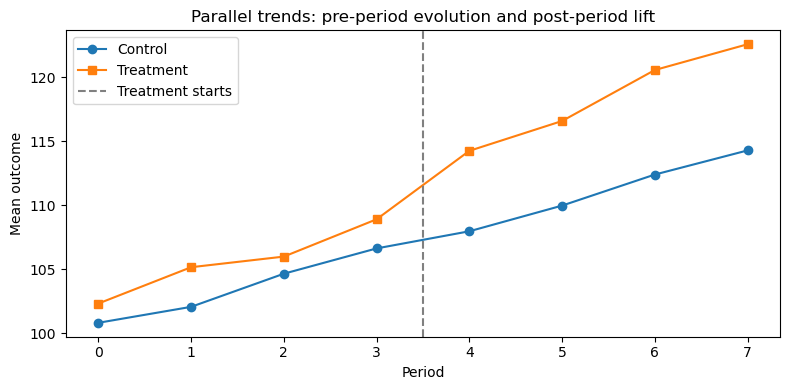

In [2]:
means = df.groupby(["period", "treated"])["y"].mean().unstack(level=1)
means.columns = ["Control", "Treatment"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(means.index, means["Control"], marker="o", label="Control")
ax.plot(means.index, means["Treatment"], marker="s", label="Treatment")
ax.axvline(x=n_periods_pre - 0.5, color="gray", linestyle="--", label="Treatment starts")
ax.set_xlabel("Period")
ax.set_ylabel("Mean outcome")
ax.legend()
ax.set_title("Parallel trends: pre-period evolution and post-period lift")
plt.tight_layout()
plt.show()

*Regression model (pre-period only):* $Y_{gt} = \alpha + \beta_1 \text{period}_t + \beta_2 D_g + \gamma\,(\text{period}_t \times D_g) + \varepsilon_{gt}$. Test $H_0: \gamma = 0$ (same trend). High p-value $\Rightarrow$ consistent with parallel trends.

In [11]:
# Pre-period data only
df_pre = df[df["post"] == 0].copy()

# Regression: same trend in pre-period means interaction period:treated is zero
pre_trend_model = smf.ols("y ~ period * treated", data=df_pre).fit(
    cov_type="cluster", cov_kwds={"groups": df_pre["geo"]}
)
print(pre_trend_model.summary())

# Key test: H0 = parallel trends (no period×treated interaction)

p_interaction = pre_trend_model.pvalues["period:treated"]
print(f"\nParallel trends check: p-value for period×treated = {p_interaction:.4f}")
if p_interaction > 0.05:
    print("→ Fail to reject H0: pre-period trends are not significantly different (consistent with parallel trends).")
else:
    print("→ Reject H0: pre-period trends differ; parallel trends assumption may be violated.")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.060
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     37.40
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           1.02e-12
Time:                        15:55:31   Log-Likelihood:                -741.81
No. Observations:                 200   AIC:                             1492.
Df Residuals:                     196   BIC:                             1505.
Df Model:                           3                                         
Covariance Type:              cluster                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        100.5300      2.067     48.

---
## 5. Estimating the Effect: 2×2 Table

Aggregate to one pre and one post value per geo, then compute the four cell means and $\tau_{\text{DiD}}$.

In [3]:
agg = df.groupby(["geo", "treated", "post"], as_index=False)["y"].mean()

pre = agg[agg["post"] == 0].groupby("treated")["y"].mean()
post = agg[agg["post"] == 1].groupby("treated")["y"].mean()

print("2×2 means:")
print(pd.DataFrame({"Pre": pre, "Post": post}))

did_2x2 = (post[1] - pre[1]) - (post[0] - pre[0])
print(f"\nDiD estimate (2×2): {did_2x2:.4f}  (true τ = {tau})")

2×2 means:
                Pre        Post
treated                        
0        103.537177  111.162455
1        105.593400  118.510369

DiD estimate (2×2): 5.2917  (true τ = 5)


---
## 6. Estimating the Effect: Regression (Two-Way Specification)

Fit $Y_{gt} = \alpha + \beta_1 D_g + \beta_2 \text{Post}_t + \tau (D_g \times \text{Post}_t) + \varepsilon_{gt}$. The coefficient on the interaction is $\hat{\tau}$.

In [4]:
model = smf.ols("y ~ treated * post", data=df).fit()
print(model.summary())
tau_hat = model.params["treated:post"]
print(f"\nτ̂ (treated:post) = {tau_hat:.4f}")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.233
Method:                 Least Squares   F-statistic:                     41.37
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           2.83e-23
Time:                        13:51:53   Log-Likelihood:                -1502.9
No. Observations:                 400   AIC:                             3014.
Df Residuals:                     396   BIC:                             3030.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      103.5372      1.041     99.414   

---
## 7. Equivalence: 2×2 Table vs Regression

The 2×2 DiD and the regression coefficient on $D_g \times \text{Post}_t$ are numerically the same (up to numerical precision).

In [5]:
assert np.isclose(did_2x2, tau_hat), "2×2 and regression DiD should match"
print(f"2×2 DiD = {did_2x2:.6f}, Regression τ̂ = {tau_hat:.6f}")
print("Match: ✓")

2×2 DiD = 5.291690, Regression τ̂ = 5.291690
Match: ✓


---
## 8. Inference: Cluster-Robust Standard Errors

Treatment is assigned at the **geo** level, so outcomes within a geo are correlated across periods. Standard OLS standard errors assume i.i.d. errors and can be severely biased. We use **cluster-robust** standard errors with clusters = geo (Bertrand et al., 2004).

In [15]:
model_cl = smf.ols("y ~ treated * post", data=df).fit(
    cov_type="cluster", cov_kwds={"groups": df["geo"]}
)
print(model_cl.summary())

tau_hat_cl = model_cl.params["treated:post"]
se_cl = model_cl.bse["treated:post"]
ci_low = model_cl.conf_int().loc["treated:post", 0]
ci_high = model_cl.conf_int().loc["treated:post", 1]
print(f"\nτ̂ = {tau_hat_cl:.4f}, SE(cluster) = {se_cl:.4f}")
print(f"95% CI: [{ci_low:.4f}, {ci_high:.4f}]")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.233
Method:                 Least Squares   F-statistic:                     400.9
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           1.84e-34
Time:                        17:55:42   Log-Likelihood:                -1502.9
No. Observations:                 400   AIC:                             3014.
Df Residuals:                     396   BIC:                             3030.
Df Model:                           3                                         
Covariance Type:              cluster                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      103.5372      2.077     49.853   

---
## 9. Power Analysis

**Why it matters:** For geo DiD experiments we should consider power in two ways:

1. **Design (before the experiment):** Choose number of geos and length of pre/post so that we have adequate power (e.g. 80%) to detect a **minimum detectable effect (MDE)** of interest. Underpowered designs often yield non-significant results even when an effect exists.
2. **Interpretation (after):** If the result is non-significant, a power or MDE calculation tells us whether we could have detected a given effect size — helping distinguish "no effect" from "test was too weak."

**Approach:** With clustering and DiD, closed-form power formulas are less common; **simulation-based power** is standard. We repeatedly generate data from the same design (with a true effect τ), run the DiD test with cluster-robust SEs, and count how often we reject H₀ at α = 0.05. That proportion is the **empirical power**.

In [12]:
def run_one_did_sim(n_geos, n_treatment_geos, n_periods_pre, n_periods_post, baseline, trend, tau_true, sigma_geo=10, sigma_noise=3, seed=None):
    """Generate one geo DiD dataset and return p-value for H0: τ = 0 (cluster-robust)."""
    if seed is not None:
        np.random.seed(seed)
    geos = np.arange(n_geos)
    treatment_geos = np.random.choice(geos, size=n_treatment_geos, replace=False)
    D = np.isin(geos, treatment_geos)
    rows = []
    for g in geos:
        geo_baseline = baseline + np.random.normal(0, sigma_geo)
        for t in range(n_periods_pre + n_periods_post):
            is_post = 1 if t >= n_periods_pre else 0
            y0 = geo_baseline + trend * t + np.random.normal(0, sigma_noise)
            y = y0 + (tau_true if (D[g] and is_post) else 0)
            rows.append({"geo": g, "period": t, "post": is_post, "treated": int(D[g]), "y": y})
    sim_df = pd.DataFrame(rows)
    model = smf.ols("y ~ treated * post", data=sim_df).fit(
        cov_type="cluster", cov_kwds={"groups": sim_df["geo"]}
    )
    return model.pvalues["treated:post"]

# Power: proportion of rejections when true effect is τ (e.g. 5)
n_sims = 500
alpha = 0.05
pvals = [run_one_did_sim(n_geos, n_treatment_geos, n_periods_pre, n_periods_post, baseline, trend, tau, seed=i) for i in range(n_sims)]
power = np.mean(np.array(pvals) < alpha)
print(f"Design: {n_geos} geos ({n_treatment_geos} treated), {n_periods_pre} pre + {n_periods_post} post periods")
print(f"True effect τ = {tau}, α = {alpha}")
print(f"Empirical power (proportion of sims with p < {alpha}): {power:.2%}")

# Optional: type I error when τ = 0 (should be ~ α)
pvals_null = [run_one_did_sim(n_geos, n_treatment_geos, n_periods_pre, n_periods_post, baseline, trend, tau_true=0, seed=i) for i in range(n_sims)]
type_i = np.mean(np.array(pvals_null) < alpha)
print(f"\nType I error check (τ=0): rejection rate = {type_i:.2%} (expected ≈ {alpha:.0%})")

Design: 50 geos (25 treated), 4 pre + 4 post periods
True effect τ = 5, α = 0.05
Empirical power (proportion of sims with p < 0.05): 100.00%

Type I error check (τ=0): rejection rate = 5.60% (expected ≈ 5%)


In [13]:
# Cluster-robust inference is computed in the "Inference: Cluster-Robust Standard Errors" section above.
# Variables model_cl, tau_hat_cl, se_cl, ci_low, ci_high are available for use below (e.g. in Power Analysis).
pass

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.233
Method:                 Least Squares   F-statistic:                     400.9
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           1.84e-34
Time:                        15:57:00   Log-Likelihood:                -1502.9
No. Observations:                 400   AIC:                             3014.
Df Residuals:                     396   BIC:                             3030.
Df Model:                           3                                         
Covariance Type:              cluster                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      103.5372      2.077     49.853   

---
## 10. Assumptions and Best Practices

1. **Randomization:** Treatment (which geos get the intervention) should be assigned at random. That supports the parallel trends assumption and causal interpretation.

2. **Parallel trends:** In the absence of treatment, $E[Y_{gt}(0) \mid D_g]$ would have the same *change* from pre to post for treated and control geos. Check with pre-period trends (Section 4) or placebo tests.

3. **No spillover:** Treatment in one geo does not affect outcomes in other geos (SUTVA). With geos, spillover can be a concern; choose geo units and timing accordingly.

4. **Cluster at the level of treatment:** Always use cluster-robust standard errors at the geo level (Section 8).

5. **Aggregation:** Use one outcome per geo per period (e.g., mean revenue per user per geo per week). Avoid double-counting by defining the unit of observation consistently.

---

**Summary:** For a geo DiD experiment: (1) define pre/post and aggregate outcome per geo-period; (2) check parallel trends (visual + pre-period regression); (3) estimate τ via 2×2 or regression; (4) report cluster-robust SEs and CIs; (5) use power analysis at design and when interpreting non-significant results.

**References:** Angrist & Pischke, *Mostly Harmless Econometrics*; Bertrand, Duflo & Mullainathan (2004), "How Much Should We Trust Differences-In-Differences?"; Cunningham, *Causal Inference: The Mixtape*.